# ___Experimenting with Copilot Premium for semantic segmentation mask annotations___
-------------

In [1]:
!python --version

Python 3.14.7


The system cannot find the path specified.


In [5]:
import json
import os
from PIL import Image

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import pycocotools.mask as mask
import cv2

In [4]:
root = np.array(Image.open(r"../../../LeicaMZ12/Usables/20260407_091958.jpg").convert("RGB")) # the microscope image - colour
root.shape

(4327, 3245, 3)

In [58]:
def overlay_annotations(
    axes: Axes, masks: NDArray[np.integer | np.floating], height: int, width: int, alpha: float = 0.35, borders: bool = True
) -> Axes:
    """
    overlay segmentation results of a segmentation model on an image (or empty axes)
    the parameter `masks` is expected to be a 3 dimensional numpy array of shape (N, H, W) where N is the number of binary masks,
    H is expected to match the height of the image and W is expected to match the width of the image.
    each mask in the masks object is expected to be transformable to a boolean matrix, to subset the pixels that need colouring during plotting.
    alpha is transparency applied to the mask when it's overlaid on the image, for better transparency, use higher alpha values.
    borders is to specify whether a border needs to be drawn, outlining each segmentation result, instead of using colours alone to delineate the objects.
    """

    assert masks.shape[1] == height and masks.shape[2] == width, "dimensions of the masks do not match the params height and width"

    rgba = np.ones((height, width, 4))
    for mask in masks:
        rgba[:, :, 3] = 0  # set all the alpha channel values to 0
        # use the boolean mask to cherry pick the elements where the mask applies
        rgba[mask.astype(np.bool), :] = np.array(
            [*np.random.random(3), alpha]
        )  # and update the colour (RGB) values with the specified alpha value
        axes.imshow(rgba)  # type: ignore

        if borders:  # this block of code is adapted from https://github.com/facebookresearch/sam2/blob/main/notebooks/automatic_mask_generator_example.ipynb
            contours, _ = cv2.findContours(mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)  # type: ignore
            # try to smooth contours
            contours = [cv2.approxPolyDP(contour, epsilon=0.01, closed=True) for contour in contours]  # type: ignore
            cv2.drawContours(image=rgba, contours=contours, contourIdx=-1, color=(0, 0, 1, alpha), thickness=1)
    return axes

In [34]:
# Copilot generated COCO mask - with two classes - root and hyphae

with open(file=r"\\ad.uws.edu.au\dfshare\HomesBNK$\90963425\Downloads\root_hyphae_coco_rle.json", mode="rt") as fp: # RLE encoded COCO JSON file
    copilot_annotation = json.load(fp)

In [35]:
copilot_annotation.keys()

dict_keys(['info', 'images', 'categories', 'annotations'])

In [36]:
copilot_annotation["images"]

[{'id': 1, 'file_name': '20260407_091958.jpg', 'width': 864, 'height': 1536}]

In [37]:
copilot_annotation["categories"]

[{'id': 1, 'name': 'root'}, {'id': 2, 'name': 'hyphae'}]

In [38]:
copilot_annotation["annotations"][0]["segmentation"].keys()

dict_keys(['size', 'counts'])

In [59]:
copilot_annotation["annotations"][0]["segmentation"]["size"] # this does not match the original image dimensions????
# appears that files get shrunk when uploading to Copilot - need to find a workaround
# link sharing from OneDrive won't work because of the POS IT policies does not allow open sharing outside the institution

[1536, 864]

In [40]:
copilot_annotation["annotations"][0]["segmentation"]["counts"][:10] # pycocotools.mask.decode() expects this to be a byte array!!!!

'bl0[5fZ1O0'

In [45]:
len(copilot_annotation["annotations"]) # has 9 segmentation masks

9

In [57]:
copilot_masks = np.array([mask.decode(m["segmentation"]) for m in copilot_annotation["annotations"]])
copilot_masks.shape

(9, 1536, 864)

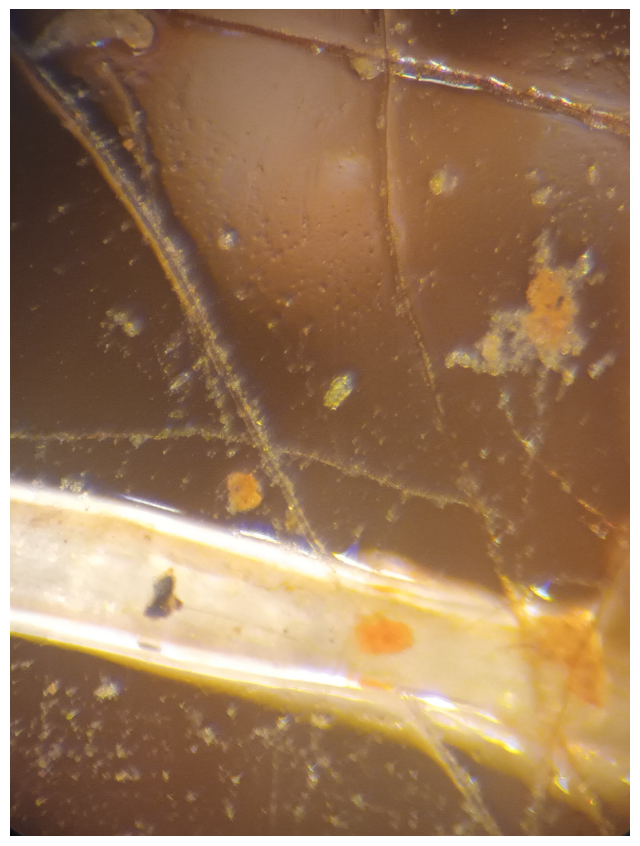

In [51]:
fig, axes = plt.subplots()
fig.set_size_inches(8, 11)
axes.set_axis_off()
axes.imshow(root)
overlay_annotations(axes = axes, masks = copilot_masks, height = , width = )
plt.show()

In [10]:
# resolutions of the image
[Image.open(f"../../../LeicaMZ12/Usables/{f}").size for f in os.listdir(r"../../../LeicaMZ12/Usables/") if f.endswith(r".jpg")]

[(3369, 4211),
 (3249, 4332),
 (3032, 4043),
 (3245, 4327),
 (3254, 4338),
 (3272, 4362),
 (3215, 4287),
 (3184, 4245)]

In [ ]:
# we need to make sure that all images have the same resolution